# Model 3 -- Two-Higgs-Doublet Model: custodial and alignment limits

G. C. Branco et al., *Phys. Rept.* **516** (2012); benchmark planes from arXiv:1507.04281.


The CP-conserving, softly broken $Z_2$-symmetric two-Higgs-doublet model adds a second scalar doublet to the Standard Model, producing two neutral scalars, one pseudoscalar, and a charged scalar pair. Its low-energy phenomenology is set by the mixing angle $\beta-\alpha$ -- whether the light Higgs looks Standard-Model-like, the *alignment limit* -- and by mass splittings among the new states, which the electroweak oblique parameter $T$ constrains strongly, favoring the *custodial-symmetry limit* $m_{H^\pm}\simeq m_A$ or $m_{H^\pm}\simeq m_H$.

**What this notebook does.** BSMScanner separates *what a model is* (a declarative YAML specification: parameters, priors, derived quantities, observables, validity conditions, likelihoods) from *how it is scanned* (one of several interchangeable search engines). This notebook loads the model below, runs a small, fast scan live so you can see the mechanics end to end, and then loads the matched-budget, fixed-seed comparison across all four engines from the companion paper's benchmark study, together with its best-fit / allowed-region result and figure. The live demo uses a short budget and an illustrative seed — it is not the published comparison, and is not expected to reproduce it exactly.


## 1. Load the framework and the model

In [1]:
import sys, pathlib
REPO_ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "python"))

import pandas as pd
from bsm_scanner import load_model, compile_model, run_scan
import bsm_scanner

print("bsm_scanner", bsm_scanner.__version__)
print("repo root  :", REPO_ROOT)

bsm_scanner 0.1.2
repo root  : /sessions/rcw-012reqeed7ksc6e9zagwhruw/mnt/BSMScanner


## 2. The model specification

Every scanned parameter, its prior, and its range come straight out of the model's YAML file (`../models/two_higgs_doublet/model.yaml`); nothing here is hand-written Python.

In [2]:
model = load_model("../models/two_higgs_doublet/model.yaml")
print("model    :", model.metadata.name)
print("params   :", len(model.parameters), "scanned")
print("theory checks:", len(model.theory_checks))
print("likelihood terms:", len(model.likelihoods))

pd.DataFrame(
    [{"name": p.name, "prior": p.prior.value, "lower": p.lower, "upper": p.upper, "default": p.default}
     for p in model.parameters]
)

model    : two_higgs_doublet_cp_conserving
params   : 6 scanned
theory checks: 3
likelihood terms: 3


,name,prior,lower,upper,default
0,mH,log,130.0,2000.0,600.00
1,mA,log,130.0,2000.0,620.00
2,mHp,log,130.0,2000.0,650.00
3,tanb,log,0.5,60.0,2.00
4,cos_ba,flat,-0.3,0.3,0.02
5,m12sq,flat,0.0,1000000.0,120000.00


Likelihood terms declared on the model:

In [3]:
pd.DataFrame(
    [{"name": t.name, "kind": t.kind.value, "observable": t.observable} for t in model.likelihoods]
)

,name,kind,observable
0,alignment_higgs_signal,gaussian,HiggsSignalStrength
1,oblique_T_constraint,gaussian,ObliqueTProxy
2,charged_higgs_lower_bound_proxy,hard_cut,ChargedHiggsMass


For reference, here is the parameter block exactly as written in the YAML (this is the entire declarative input the physics below is built from):

In [4]:
print(pathlib.Path("../models/two_higgs_doublet/model.yaml").read_text())

metadata:
  name: two_higgs_doublet_cp_conserving
  version: 0.1.0
  description: CP-conserving softly-broken Z2 two-Higgs-doublet benchmark in physical-mass variables with Higgs-signal, oblique-T, perturbativity, and stability proxy observables.
  tags: [2hdm, two_higgs_doublet, higgs_sector, cp_conserving]
parameters:
- {name: mH, value_type: real, scan: true, lower: 130.0, upper: 2000.0, default: 600.0, prior: log}
- {name: mA, value_type: real, scan: true, lower: 130.0, upper: 2000.0, default: 620.0, prior: log}
- {name: mHp, value_type: real, scan: true, lower: 130.0, upper: 2000.0, default: 650.0, prior: log}
- {name: tanb, value_type: real, scan: true, lower: 0.5, upper: 60.0, default: 2.0, prior: log}
- {name: cos_ba, value_type: real, scan: true, lower: -0.3, upper: 0.3, default: 0.02, prior: flat}
- {name: m12sq, value_type: real, scan: true, lower: 0.0, upper: 1000000.0, default: 120000.0, prior: flat}
constants:
- {name: mh, value: 125.25}
- {name: v_sm, value: 246.22}
- {n

## 3. A quick, live scan

This runs `serial_random` for `3000` evaluations at a throwaway seed, right here, so you can see the mechanics end to end in a few seconds. It is deliberately small and is **not** the matched-budget comparison used in the study below.

In [5]:
# A small, fast, live demo -- NOT the matched-budget study below.
model.scan.engine = "serial_random"
model.scan.seed = 1
model.scan.settings["max_evaluations"] = 3000

compiled = compile_model(model)
demo = run_scan(model, compiled, run_directory="runs/two_higgs_doublet_demo")

n_eval = demo.summary["evaluations"]
n_valid = demo.summary["valid_points"]
print("evaluations  :", n_eval)
print("valid points :", n_valid, "(%.1f%% of this quick run)" % (100.0 * n_valid / n_eval))
print("best nLL in this quick run:", demo.summary["best_metric_value"])

points = pd.read_csv(demo.points_path)
points.head()

evaluations  : 3000
valid points : 169 (5.6% of this quick run)
best nLL in this quick run: 2.378726709688752e-05


,evaluation,status,valid,failure_reason,scanner_target,metric_value,total_nll,param::mH,param::mA,param::mHp,...,output::ObliqueTProxy,output::MaxAbsQuarticProxy,output::lambda1_proxy,output::lambda2_proxy,output::lambda3_proxy,output::lambda4_proxy,output::lambda5_proxy,likelihood::alignment_higgs_signal,likelihood::charged_higgs_lower_bound_proxy,likelihood::oblique_T_constraint
0,1,ok,False,theory_check_failed: A 2HDM quartic proxy exce...,1.000000e+12,1.000000e+12,0.0,187.442,188.743,446.246,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,ok,False,theory_check_failed: A 2HDM quartic proxy exce...,1.000000e+12,1.000000e+12,0.0,470.725,159.328,617.165,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,ok,False,theory_check_failed: A 2HDM quartic proxy exce...,1.000000e+12,1.000000e+12,0.0,1125.460,238.255,408.262,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,ok,False,theory_check_failed: A 2HDM quartic proxy exce...,1.000000e+12,1.000000e+12,0.0,475.694,271.885,284.119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,ok,False,theory_check_failed: A 2HDM quartic proxy exce...,1.000000e+12,1.000000e+12,0.0,313.256,177.129,180.147,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. The published engine comparison

Matched budget (~30k), identical seed (20260816). Both Gaussian terms (alignment, oblique-$T$) reach exactly zero and constrain disjoint parameters, so the optimum is again $n$LL$=0$ exactly -- but here the *theory checks* bite hard: the perturbativity proxy rejects large mass splittings, and the validity boundary, not the likelihood, is what shapes the space. Coverage counts occupied cells on a 20x20 grid over $(\log m_A,\log m_{H^\pm})$ among near-optimal points.

In [6]:
pd.DataFrame([{'engine': 'serial_random', 'evaluations': 30000, 'valid': 1809, 'valid_pct': '6.0%', 'best_nLL': '3.57e-07', 'coverage': '2/400'}, {'engine': 'de_scipy', 'evaluations': 50183, 'valid': 3941, 'valid_pct': '7.9%', 'best_nLL': '1.96e-07', 'coverage': '5/400'}, {'engine': 'adaptive_diver', 'evaluations': 21300, 'valid': 20176, 'valid_pct': '94.7%', 'best_nLL': '8.4e-33', 'coverage': '59/400'}, {'engine': 'basin_scan', 'evaluations': 18661, 'valid': 4369, 'valid_pct': '23.4%', 'best_nLL': '4.36e-18', 'coverage': '2/400'}])[['engine', 'evaluations', 'valid', 'valid_pct', 'best_nLL', 'coverage']]

,engine,evaluations,valid,valid_pct,best_nLL,coverage
0,serial_random,30000,1809,6.0%,3.57e-07,2/400
1,de_scipy,50183,3941,7.9%,1.96e-07,5/400
2,adaptive_diver,21300,20176,94.7%,8.4e-33,59/400
3,basin_scan,18661,4369,23.4%,4.36e-18,2/400


`adaptive_diver` dominates on every axis: 94.7% valid against 6.0% for random sampling (a 16x efficiency gap), the optimum at evaluation 762 rather than 10,809, and 30x the coverage. When a restrictive validity boundary dominates, an engine that *learns* where the valid region is wins decisively -- the inverse of the B-L result, where 72-99% of the prior box was valid and there was nothing to learn.

## 5. Physics result: the custodial limit is recovered (16,451 pooled near-optimal points)

In [7]:
pd.DataFrame([{'quantity': 'nLL at optimum', 'result': '0 (exact), degenerate'}, {'quantity': 'median |cos(beta-alpha)|', 'result': '3.6e-6 (alignment limit)'}, {'quantity': 'median |m_A - m_Hpm|', 'result': '0.038 GeV'}, {'quantity': 'median |m_H - m_Hpm|', 'result': '0.026 GeV'}, {'quantity': 'm_Hpm within 20 GeV of m_A or m_H', 'result': '100.0%'}])[['quantity', 'result']]

,quantity,result
0,nLL at optimum,"0 (exact), degenerate"
1,median |cos(beta-alpha)|,3.6e-6 (alignment limit)
2,median |m_A - m_Hpm|,0.038 GeV
3,median |m_H - m_Hpm|,0.026 GeV
4,m_Hpm within 20 GeV of m_A or m_H,100.0%


The scan independently reproduces the textbook 2HDM result: the oblique-$T$ constraint forces $m_{H^\pm}\simeq m_A$ **or** $m_{H^\pm}\simeq m_H$ -- the custodial-symmetry limit -- while the Higgs signal strength forces alignment. Nothing in the model states this explicitly; it emerges from the fit.

### Figure

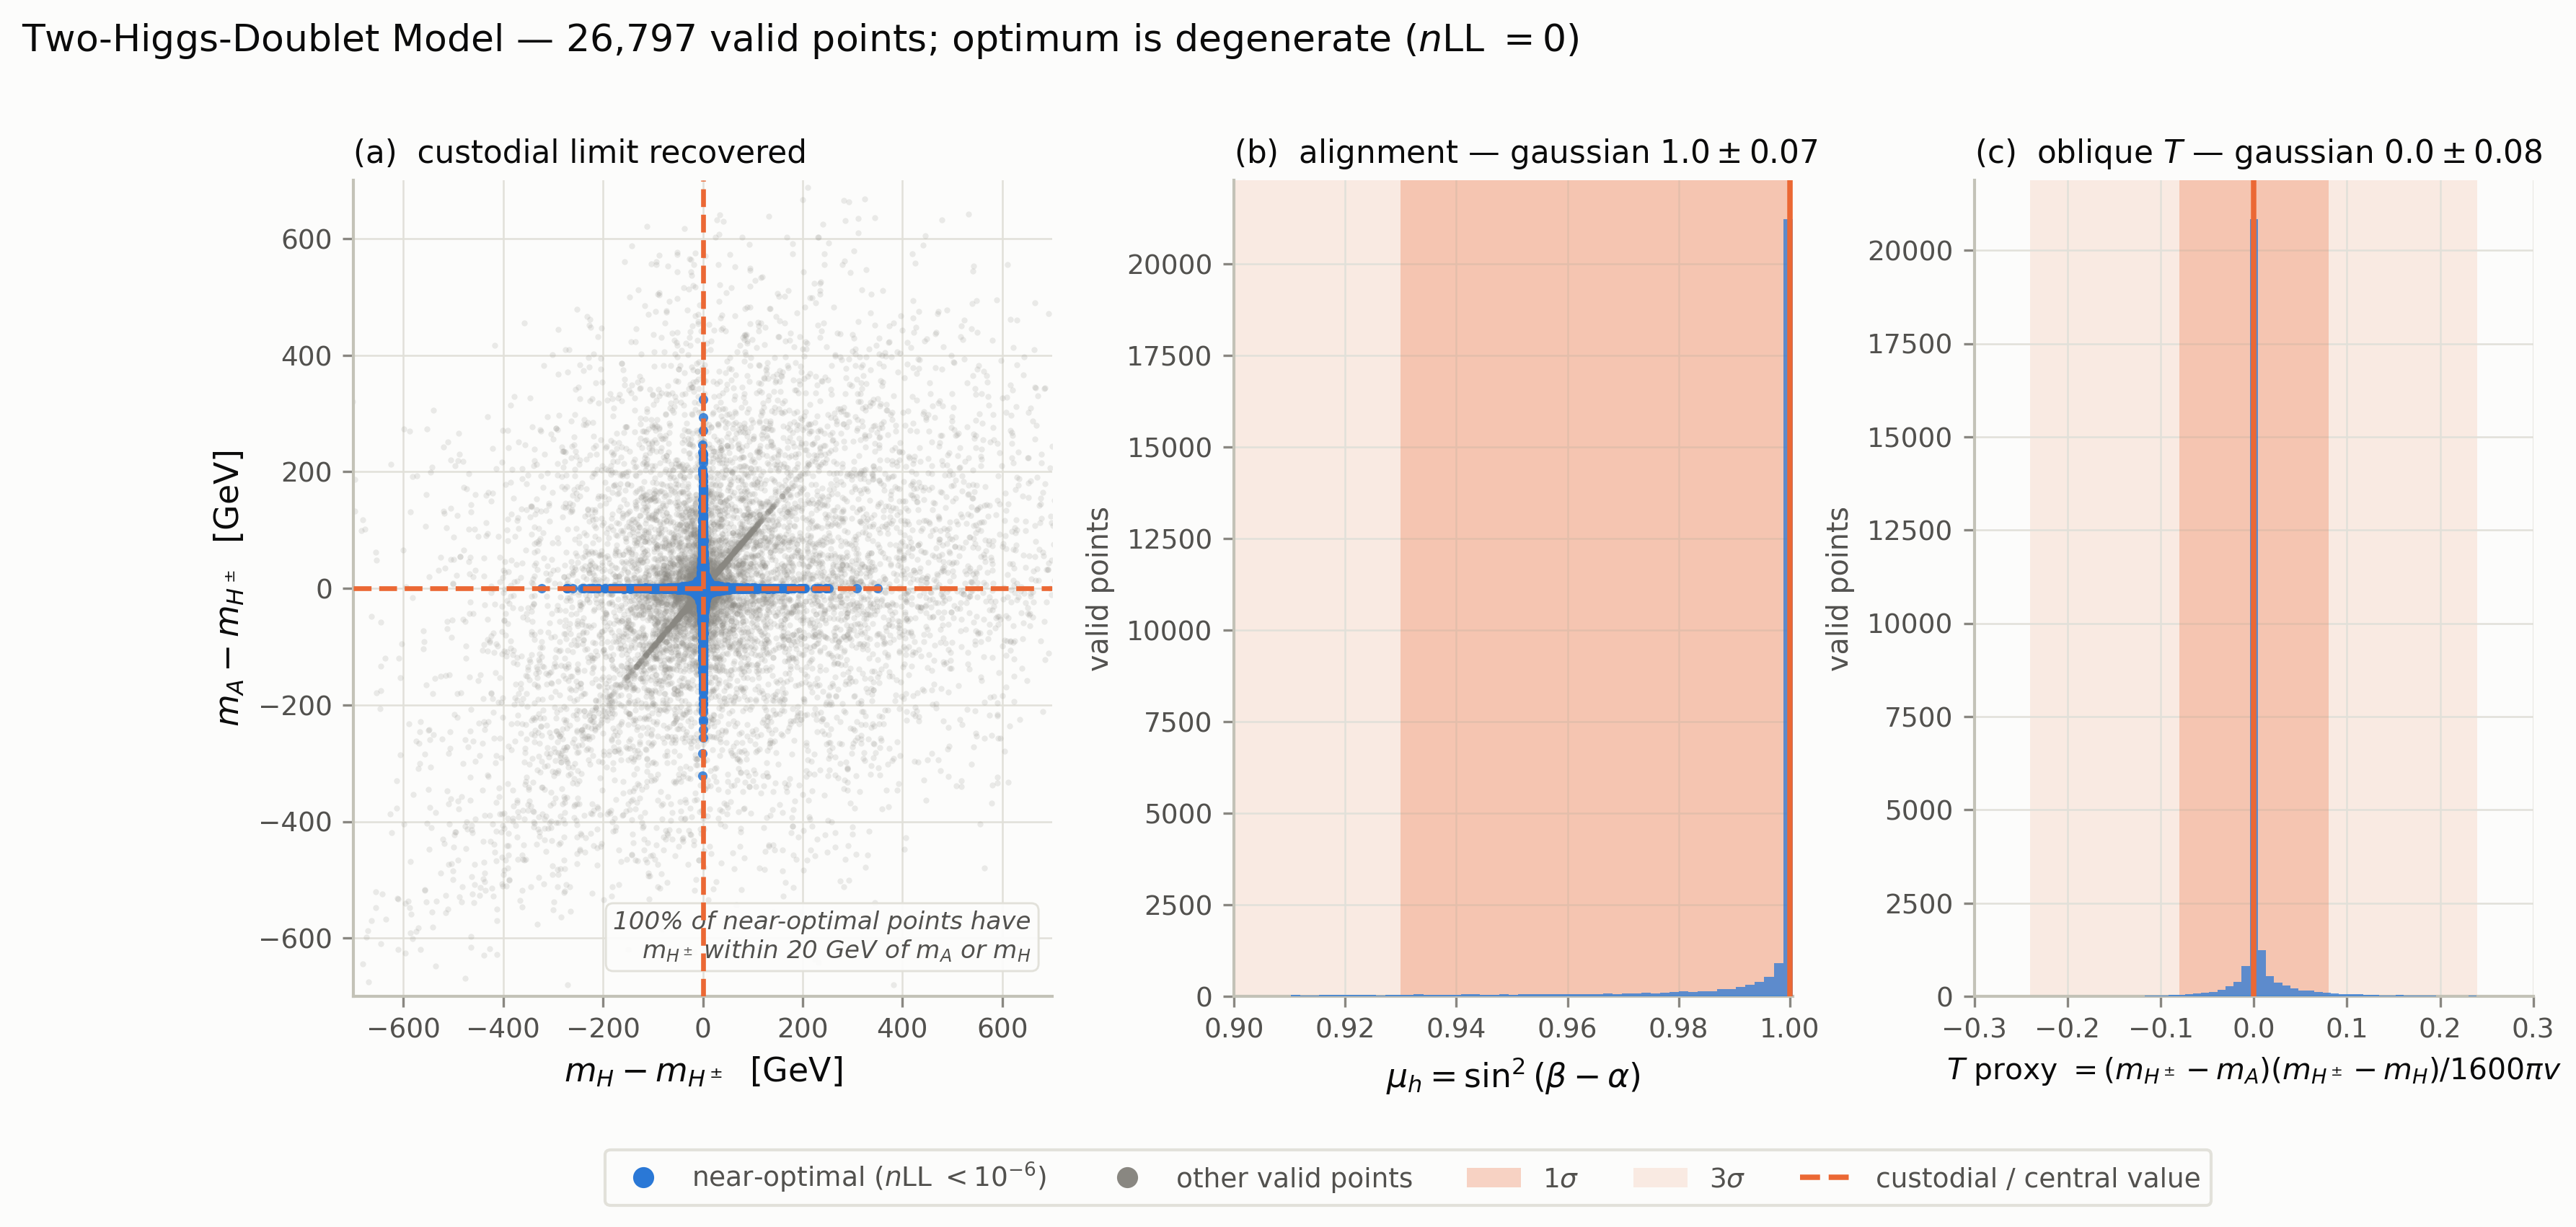

In [8]:
from IPython.display import Image, display
display(Image(filename="figures/two_higgs_doublet.png"))

The two custodial branches in the (m_H - m_Hpm, m_A - m_Hpm) plane, lying exactly along the axes.

## 6. Caveats

The quartics, stability and $T$ constraint here are lightweight proxies. In particular the charged-Higgs lower-bound proxy is inactive by construction (it duplicates the prior's own lower bound); the real experimental bound ($m_{H^\pm}\gtrsim580$ GeV in Type-II from $b\to s\gamma$) is far stronger than the 130 GeV used here. Replacing these with 2HDMC plus HiggsBounds/HiggsSignals would cut the allowed region substantially at low $m_{H^\pm}$ and low $\tan\beta$.

## 7. Reproducing the full study

The cell below is exactly the pattern used to produce the table in section 4 — shown, not executed, since a full matched-budget run can take a while.

In [ ]:
# NOT executed in this notebook (can take from seconds to several minutes per
# engine). Reproduces the matched-budget comparison from the study: seed
# 20260816, ~30k evaluations, one row per engine.
rows = []
for engine in ["serial_random", "de_scipy", "adaptive_diver", "basin_scan"]:
    m = load_model("../models/two_higgs_doublet/model.yaml")
    m.scan.engine = engine
    m.scan.seed = 20260816
    m.scan.settings["max_evaluations"] = 30000
    c = compile_model(m)
    r = run_scan(m, c, run_directory=f"runs/{engine}_matched")
    rows.append({"engine": engine, **r.summary})
pd.DataFrame(rows)

---
BSMScanner: a declarative parameter-scanning framework for BSM physics. See the companion paper for the full seven-benchmark methodology study, and `notebooks/t43i_b1.ipynb` for a worked physics application built on top of it.